# Distorted Visual Sequence Recognition — Residual CRNN

**Problem:** Recognize text sequences from noisy/distorted grayscale images  
**Metric:** Character Error Rate (CER)  

## Key Design Choices

- **CNN Backbone:** ResNet-style residual blocks were used because skip connections help preserve information across layers and make deeper networks easier to train.

- **Sequence Model:** A Bidirectional LSTM was chosen so that the model can use both past and future context while recognizing text sequences.

- **Loss Function:** CTC Loss was used since character positions are not explicitly aligned with image regions, making it suitable for OCR tasks.

- **Optimizer:** AdamW was selected for stable convergence along with better regularization through weight decay.

- **Learning Rate Scheduler:** CosineAnnealingLR gradually reduces the learning rate during training, helping the model converge smoothly.

- **Training Speed:** Mixed Precision (AMP) was enabled to reduce training time and GPU memory usage.

- **Robustness:** Early stopping was used to prevent unnecessary training once validation performance stopped improving.
---

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install opencv-python-headless matplotlib pandas tqdm Pillow -q
print("All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 72.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 42.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 101.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 32.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [ ]:
import os, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.7.1+cu118
Device  : cuda
GPU     : Tesla T4


In [ ]:
BASE_DIR      = "/kaggle/input/datasets/dishaaagrawal12/cig-dataset/cig_ps"
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train_images")
TRAIN_CSV     = os.path.join(BASE_DIR, "train-labels.csv")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test_images")
MODEL_PATH    = "/kaggle/working/best_crnn_residual.pth"

for name, path in [("Train images", TRAIN_IMG_DIR),
                   ("Train CSV",    TRAIN_CSV),
                   ("Test images",  TEST_IMG_DIR)]:
    ok = chr(10003) if os.path.exists(path) else 'MISSING'
    print(f"{ok}  {name}: {path}")

✓  Train images: /kaggle/input/datasets/dishaaagrawal12/cig-dataset/cig_ps/train_images
✓  Train CSV: /kaggle/input/datasets/dishaaagrawal12/cig-dataset/cig_ps/train-labels.csv
✓  Test images: /kaggle/input/datasets/dishaaagrawal12/cig-dataset/cig_ps/test_images


---
## Section 1 — Exploratory Data Analysis


Total samples : 20000
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
5           5  train-5.png  YV2C3D
6           6  train-6.png  XNBP7G
7           7  train-7.png  TGQXFU

Label length stats:
count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000
Name: label_len, dtype: float64


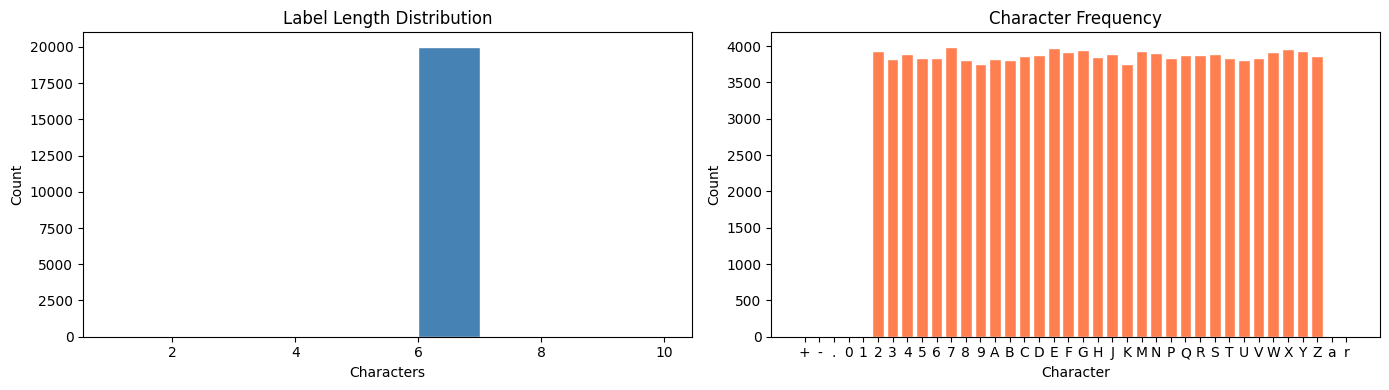

Unique chars: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


In [ ]:
df = pd.read_csv(TRAIN_CSV)
df["text"] = df["text"].astype(str)

print(f"Total samples : {len(df)}")
print(df.head(8))

df["label_len"] = df["text"].str.len()

print("\nLabel length stats:")
print(df["label_len"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["label_len"], bins=df["label_len"].max(),
             ax=axes[0])
axes[0].set_title("Label Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

all_chars = "".join(df["text"])
freq = Counter(all_chars)

char_df = pd.DataFrame({
    "Character": list(freq.keys()),
    "Count": list(freq.values())
}).sort_values("Character")

sns.barplot(data=char_df, x="Character", y="Count", ax=axes[1])
axes[1].set_title("Character Frequency")
axes[1].set_xlabel("Character")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Unique chars: {sorted(set(all_chars))}")

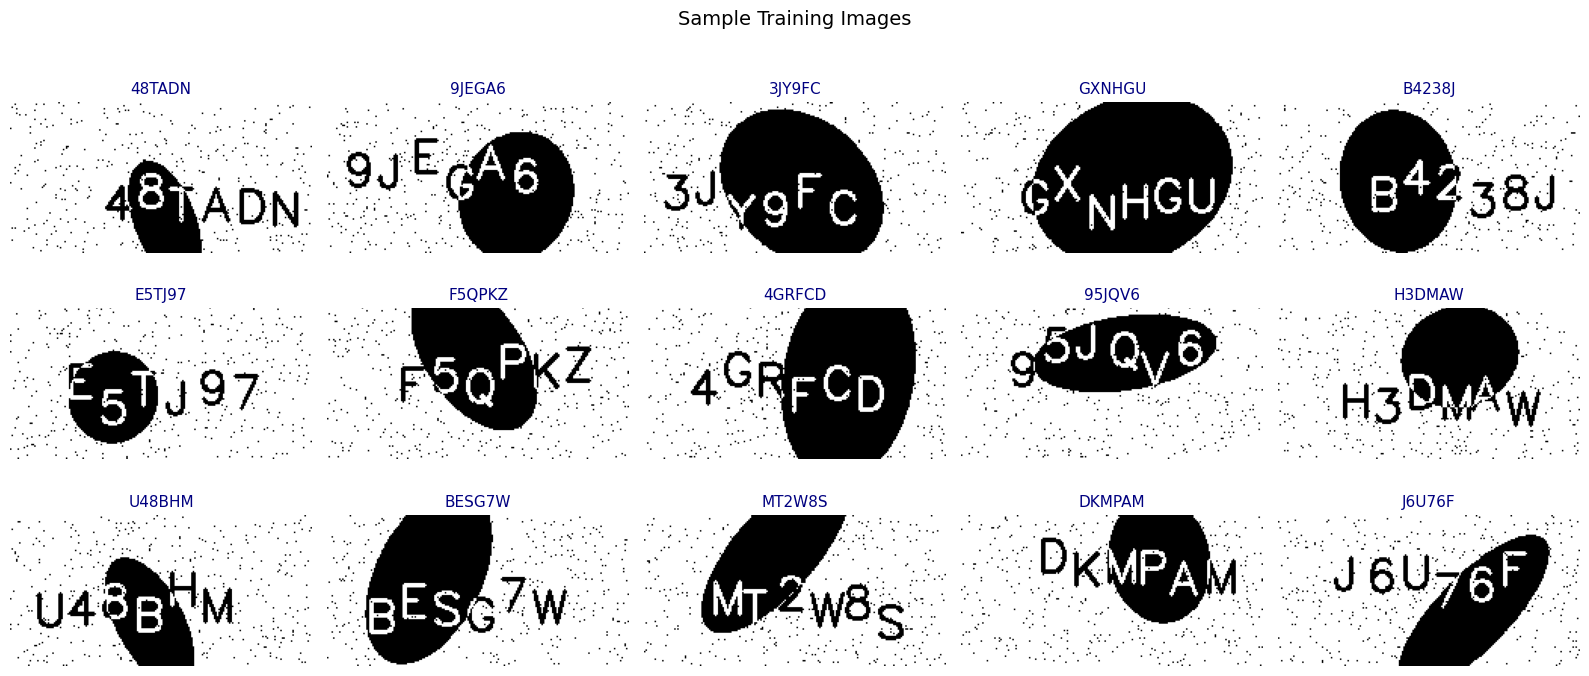

Image size: (200, 100), Mode: RGB


In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(16, 7))

sample_rows = df.sample(15, random_state=SEED).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = Image.open(
        os.path.join(TRAIN_IMG_DIR, sample_rows.iloc[i]["image"])
    ).convert("L")

    ax.imshow(img, cmap="gray")
    ax.set_title(sample_rows.iloc[i]["text"], fontsize=11, color="navy")
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

sample_img = Image.open(
    os.path.join(TRAIN_IMG_DIR, df.iloc[0]["image"])
)

print(f"Image size: {sample_img.size}, Mode: {sample_img.mode}")

---
## Section 2 — Configuration


In [ ]:
CFG = {
    "chars"        : "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",
    "img_h"        : 64,
    "img_w"        : 256,
    "batch_size"   : 64,          
    "epochs"       : 60,        
    "early_stop"   : 10,         
    "lr"           : 5e-4,
    "weight_decay" : 1e-4,
    "val_split"    : 0.10,
    "lstm_hidden"  : 256,
    "lstm_layers"  : 2,
    "dropout"      : 0.3,
    "use_amp"      : True,       
}

CHARS       = CFG["chars"]
char2idx    = {c: i+1 for i, c in enumerate(CHARS)}
idx2char    = {i+1: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS) + 1

print(f"Vocab      : {CHARS}")
print(f"Classes    : {NUM_CLASSES}  (36 chars + 1 CTC blank)")
print(f"Epochs     : {CFG['epochs']} (with early stopping patience={CFG['early_stop']})")
print(f"Mixed Prec : {CFG['use_amp']}")

Vocab      : ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789
Classes    : 37  (36 chars + 1 CTC blank)
Epochs     : 60 (with early stopping patience=10)
Mixed Prec : True


---
## Section 3 — Preprocessing & Augmentation

- **RandomAffine** helps the model handle variations in character shape and alignment.

- **GaussianBlur** makes the model robust to blurry or low-quality images.

- **RandomErasing** simulates occluded regions and missing parts of characters.

**Validation uses clean transforms only.**

In [8]:
H, W = CFG["img_h"], CFG["img_w"]

train_transform = transforms.Compose([
    transforms.Resize((H, W)),
    transforms.RandomAffine(degrees=5, shear=3, translate=(0.02, 0.02), fill=255),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.10), ratio=(0.3, 3.3)),
])

val_transform = transforms.Compose([
    transforms.Resize((H, W)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
print("Transforms defined!")

Transforms defined!


In [ ]:
class TextImageDataset(Dataset):
    """
    Loads grayscale images + text labels.
    Filters rows with characters outside vocabulary.
    """
    def __init__(self, csv_path, img_dir, transform=None):
        raw_df = pd.read_csv(csv_path)
        raw_df["text"] = raw_df["text"].astype(str)
        mask = raw_df["text"].apply(
            lambda x: len(x) > 0 and all(c in char2idx for c in x)
        )
        self.df        = raw_df[mask].reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        print(f"  Rows loaded: {len(raw_df)}  ->  Clean: {len(self.df)}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["image"])).convert("L")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor([char2idx[c] for c in row["text"]], dtype=torch.long)
        return img, label


class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir   = img_dir
        self.filenames = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img   = Image.open(os.path.join(self.img_dir, fname)).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, fname


def collate_fn(batch):
    images, labels = zip(*batch)
    return torch.stack(images, 0), list(labels)

train_full = TextImageDataset(TRAIN_CSV, TRAIN_IMG_DIR, transform=train_transform)
val_full   = TextImageDataset(TRAIN_CSV, TRAIN_IMG_DIR, transform=val_transform)

total         = len(train_full)
val_size      = int(CFG["val_split"] * total)
train_size    = total - val_size

indices = list(range(total))
random.seed(SEED)
random.shuffle(indices)
train_indices = indices[val_size:]
val_indices   = indices[:val_size]

train_ds = Subset(train_full, train_indices)  # augmented
val_ds   = Subset(val_full,   val_indices)    # clean

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          collate_fn=collate_fn, num_workers=4,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          collate_fn=collate_fn, num_workers=4,
                          pin_memory=True, persistent_workers=True)
test_ds      = TestDataset(TEST_IMG_DIR, transform=val_transform)
test_loader  = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Train: {train_size} samples | {len(train_loader)} batches")
print(f"Val  : {val_size} samples | {len(val_loader)} batches")
print(f"Test : {len(test_ds)} images")
print("train=augmented, val=clean — transforms correctly separated!")

Loading datasets...
  Rows loaded: 20000  ->  Clean: 19998
  Rows loaded: 20000  ->  Clean: 19998
Train: 17999 samples | 282 batches
Val  : 1999 samples | 32 batches
Test : 5000 images
train=augmented, val=clean — transforms correctly separated!


---
## Section 4 — Model Architecture: Residual CRNN

In [ ]:
class ResidualBlock(nn.Module):
    """
    Two conv layers with a skip connection.
    output = relu( Conv(Conv(x)) + shortcut(x) )
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Sequential()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        return F.relu(self.block(x) + self.shortcut(x), inplace=True)


class ResidualCRNN(nn.Module):
    """
    CNN (ResidualBlocks) -> AdaptivePool -> BiLSTM -> Linear -> CTC
    """
    def __init__(self, num_classes, lstm_hidden=256, lstm_layers=2, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            # Entry: 1 channel -> 64
            nn.Conv2d(1, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),               # H/2, W/2

            ResidualBlock(64, 128),
            nn.MaxPool2d(2, 2),               # H/4, W/4

            ResidualBlock(128, 256),
            nn.MaxPool2d((2, 1)),             # H/8, W/4

            ResidualBlock(256, 512),
            nn.MaxPool2d((2, 1)),             # H/16, W/4

            ResidualBlock(512, 512),
        )

        # Collapse height to 1
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

        self.lstm = nn.LSTM(
            input_size    = 512,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            bidirectional = True,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(p=dropout)
        # lstm_hidden * 2 because bidirectional concatenates forward + backward
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)                # (B, 512, H', W')
        x = self.adaptive_pool(x)      # (B, 512, 1,  W')
        x = x.squeeze(2)               # (B, 512, W')
        x = x.permute(0, 2, 1)        # (B, W', 512)
        x, _ = self.lstm(x)           # (B, W', hidden*2)
        x = self.dropout(x)
        x = self.fc(x)                 # (B, W', num_classes)
        x = x.permute(1, 0, 2)        # (W', B, num_classes) 
        return x


model = ResidualCRNN(
    num_classes = NUM_CLASSES,
    lstm_hidden = CFG['lstm_hidden'],
    lstm_layers = CFG['lstm_layers'],
    dropout     = CFG['dropout'],
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")


model.eval()
dummy = torch.randn(2, 1, CFG['img_h'], CFG['img_w']).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}  -> (T, B=2, classes={out.shape[2]}) Passed!")

Total params    : 12,716,517
Trainable params: 12,716,517
Output shape: torch.Size([64, 2, 37])  -> (T, B=2, classes=37) Passed!


---
## Section 5 — CTC Loss, Decoder & CER

**CTC Loss**: Sums probability over all valid character alignments. No per-pixel labeling needed.  
**Greedy Decode**: argmax at each timestep → collapse repeats → remove blanks.  
**CER**: `Levenshtein(pred, gt) / len(gt)` — 0.0 is perfect.

In [11]:
def greedy_decode(outputs):
    """
    outputs: Tensor (T, B, num_classes)
    returns: list of decoded strings
    """
    pred_ids = outputs.argmax(dim=2).permute(1, 0)  # (B, T)
    results = []
    for seq in pred_ids:
        chars, prev = [], -1
        for idx in seq.tolist():
            if idx != prev and idx != 0:
                chars.append(idx2char.get(idx, ''))
            prev = idx
        results.append(''.join(chars))
    return results


def levenshtein_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[j] = prev[j-1]
            else:
                dp[j] = 1 + min(prev[j], dp[j-1], prev[j-1])
    return dp[n]


def compute_cer(preds, targets):
    total_dist, total_len = 0, 0
    for pred, tgt in zip(preds, targets):
        gt = ''.join(idx2char[i.item()] for i in tgt)
        total_dist += levenshtein_distance(pred, gt)
        total_len  += max(len(gt), 1)
    return total_dist / total_len


assert levenshtein_distance('HELLO', 'HELO') == 1
assert levenshtein_distance('ABC', 'ABC')    == 0
print("Levenshtein tests passed!")

Levenshtein tests passed!


---
## Section 6 — Training with Mixed Precision & Early Stopping

### Mixed Precision (AMP)
Normally all tensors are float32 (32-bit). AMP runs forward pass in **float16**  
which is 2x smaller → fits more data in GPU memory → 2-3x faster training.  
A `GradScaler` prevents float16 underflow during backprop.

### Early Stopping
If validation CER doesn't improve for `patience=10` consecutive epochs,  
training stops automatically. Prevents wasted compute and overfitting.

In [ ]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = torch.amp.GradScaler(device_type, enabled=CFG['use_amp'])

print(f"Optimizer : AdamW  lr={CFG['lr']}, wd={CFG['weight_decay']}")
print(f"Scheduler : CosineAnnealingLR  T_max={CFG['epochs']}")
print(f"AMP       : {CFG['use_amp']}")
print(f"Loss      : CTCLoss  blank=0")

Optimizer : AdamW  lr=0.0005, wd=0.0001
Scheduler : CosineAnnealingLR  T_max=60
AMP       : True
Loss      : CTCLoss  blank=0


In [ ]:
def train_one_epoch(loader):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type, enabled=CFG['use_amp']):
            outputs = model(imgs)
            T, B, _ = outputs.shape
            log_probs     = outputs.log_softmax(2)
            input_lengths = torch.full((B,), T, dtype=torch.long, device=DEVICE)
            target_lengths= torch.tensor([len(l) for l in labels],
                                          dtype=torch.long, device=DEVICE)
            targets_flat  = torch.cat(labels).to(DEVICE)
            loss = criterion(log_probs, targets_flat, input_lengths, target_lengths)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    return running_loss / len(loader)


@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, total_cer = 0.0, 0.0
    for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type, enabled=CFG['use_amp']):
            outputs = model(imgs)
            T, B, _ = outputs.shape
            log_probs     = outputs.log_softmax(2)
            input_lengths = torch.full((B,), T, dtype=torch.long, device=DEVICE)
            target_lengths= torch.tensor([len(l) for l in labels],
                                          dtype=torch.long, device=DEVICE)
            targets_flat  = torch.cat(labels).to(DEVICE)
            loss = criterion(log_probs, targets_flat, input_lengths, target_lengths)
        total_loss += loss.item()
        preds = greedy_decode(outputs.cpu())
        total_cer += compute_cer(preds, labels)
    return total_loss / len(loader), total_cer / len(loader)


history       = {'train_loss': [], 'val_loss': [], 'val_cer': []}
best_cer      = float('inf')
patience_ctr  = 0
EPOCHS        = CFG['epochs']
PATIENCE      = CFG['early_stop']

print(f"Training for up to {EPOCHS} epochs | Early stop patience={PATIENCE}\n")

for epoch in range(1, EPOCHS + 1):
    train_loss        = train_one_epoch(train_loader)
    val_loss, val_cer = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)

    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:02d}/{EPOCHS}"
          f"  TrainLoss={train_loss:.4f}"
          f"  ValLoss={val_loss:.4f}"
          f"  ValCER={val_cer:.4f}"
          f"  LR={lr_now:.2e}")

    if val_cer < best_cer:
        best_cer     = val_cer
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  -> Best model saved! CER={best_cer:.4f}")
    else:
        patience_ctr += 1
        print(f"  (no improvement {patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nDone. Best Val CER = {best_cer:.4f}")

Training for up to 60 epochs | Early stop patience=10



Epoch 01/60  TrainLoss=4.3893  ValLoss=3.4407  ValCER=1.0000  LR=5.00e-04
  -> Best model saved! CER=1.0000


Epoch 02/60  TrainLoss=1.2277  ValLoss=0.1039  ValCER=0.0241  LR=4.99e-04
  -> Best model saved! CER=0.0241


Epoch 03/60  TrainLoss=0.1473  ValLoss=0.0108  ValCER=0.0015  LR=4.97e-04
  -> Best model saved! CER=0.0015


Epoch 04/60  TrainLoss=0.1039  ValLoss=0.0081  ValCER=0.0014  LR=4.95e-04
  -> Best model saved! CER=0.0014


...

Epoch 23/60  TrainLoss=0.0483  ValLoss=0.0009  ValCER=0.0002  LR=3.40e-04
  (no improvement 6/10)


Epoch 24/60  TrainLoss=0.0466  ValLoss=0.0010  ValCER=0.0002  LR=3.28e-04
  (no improvement 7/10)


Epoch 25/60  TrainLoss=0.0487  ValLoss=0.0009  ValCER=0.0002  LR=3.15e-04
  (no improvement 8/10)


Epoch 26/60  TrainLoss=0.0453  ValLoss=0.0006  ValCER=0.0002  LR=3.02e-04
  (no improvement 9/10)


Epoch 27/60  TrainLoss=0.0442  ValLoss=0.0006  ValCER=0.0001  LR=2.90e-04
  (no improvement 10/10)

Early stopping at epoch 27.

Done. Best Val CER = 0.0001


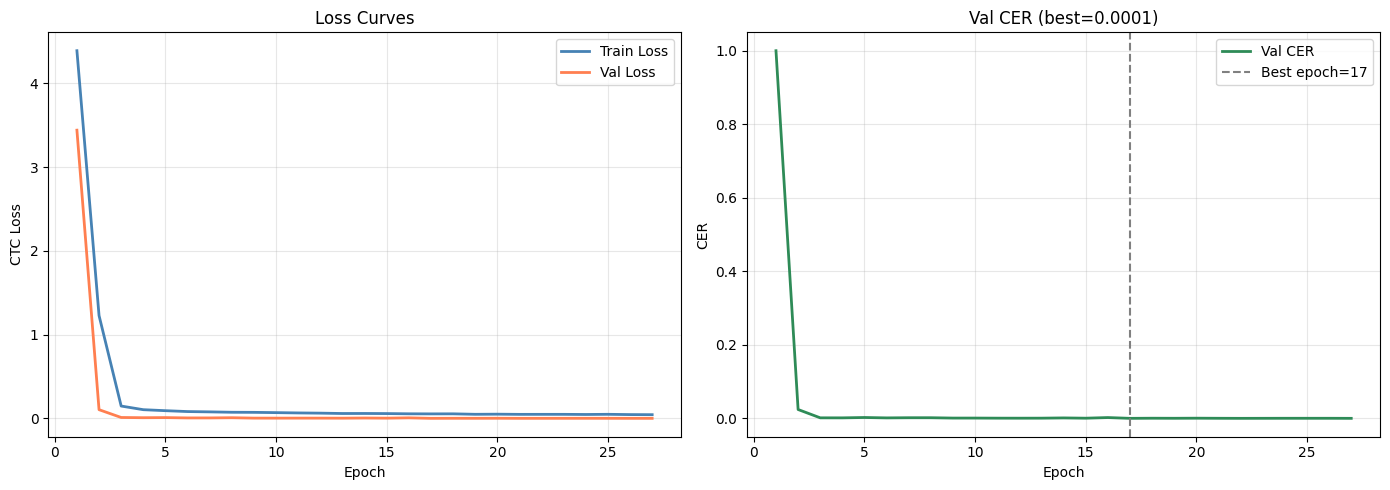

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history["train_loss"]) + 1)

sns.lineplot(x=list(ep), y=history["train_loss"], ax=axes[0], label="Train Loss")
sns.lineplot(x=list(ep), y=history["val_loss"], ax=axes[0], label="Val Loss")

axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss")
axes[0].legend()

best_e = history["val_cer"].index(min(history["val_cer"])) + 1

sns.lineplot(x=list(ep), y=history["val_cer"], ax=axes[1], label="Val CER")
axes[1].axvline(best_e, ls="--", label=f"Best epoch={best_e}")

axes[1].set_title(f"Val CER (best={min(history['val_cer']):.4f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 7 — Evaluation & Qualitative Analysis


In [15]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Best model loaded!")
_, final_cer = evaluate(val_loader)
print(f"Final Validation CER: {final_cer:.4f}")

Best model loaded!


Final Validation CER: 0.0001


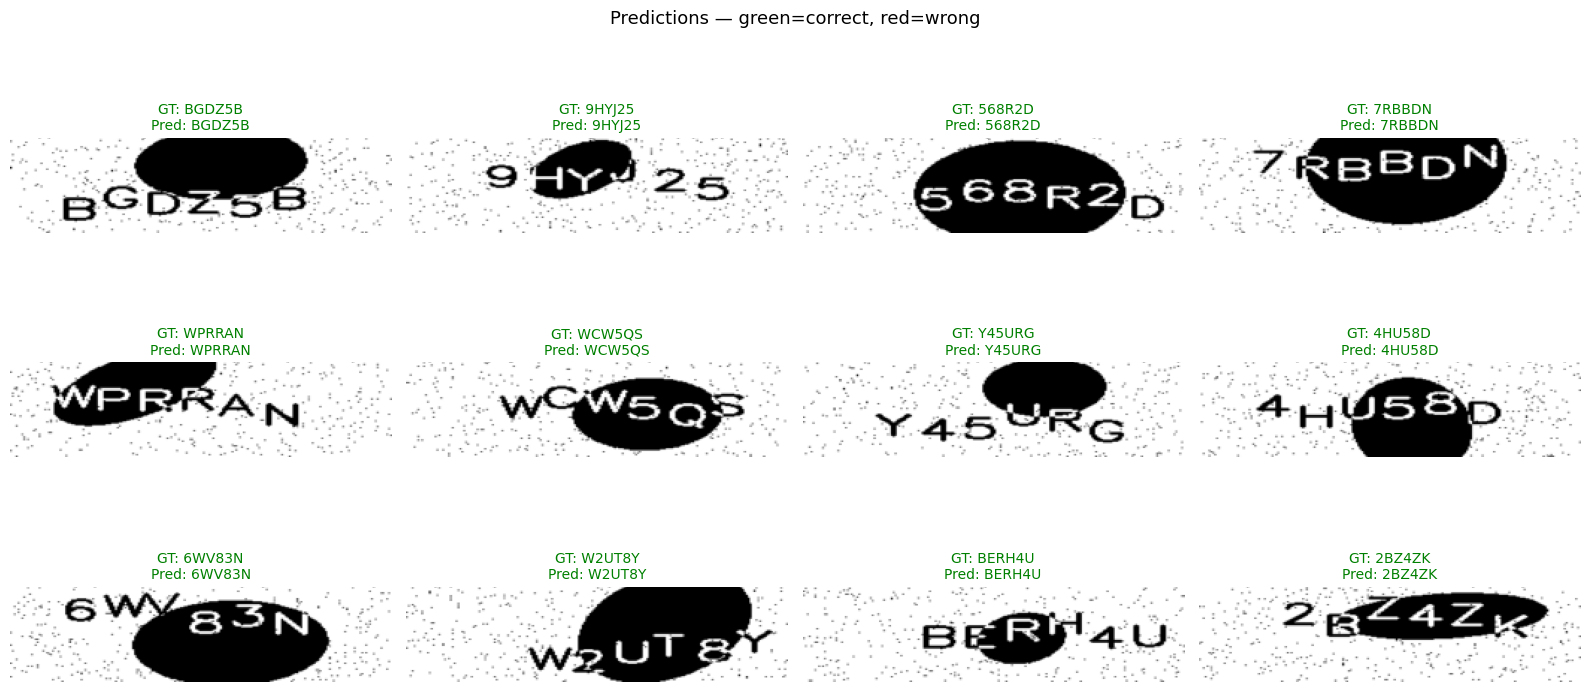

Exact matches: 12/12 = 100.0%


In [16]:
model.eval()
sample_imgs, sample_labels = next(iter(val_loader))

with torch.no_grad():
    with torch.amp.autocast(device_type, enabled=CFG['use_amp']):
        out = model(sample_imgs.to(DEVICE))

preds = greedy_decode(out.cpu())
gts   = [''.join(idx2char[i.item()] for i in lbl) for lbl in sample_labels]

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
exact = 0
for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ok     = preds[i] == gts[i]
    exact += int(ok)
    ax.set_title(f'GT: {gts[i]}\nPred: {preds[i]}',
                 fontsize=10, color='green' if ok else 'red')
    ax.axis('off')

plt.suptitle('Predictions — green=correct, red=wrong', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Exact matches: {exact}/12 = {exact/12:.1%}")

---
## Section 8 — Inference & Submission


In [17]:
model.eval()
all_fnames, all_preds = [], []

with torch.no_grad():
    for imgs, fnames in tqdm(test_loader, desc='Inferring test set'):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type, enabled=CFG['use_amp']):
            out = model(imgs)
        decoded = greedy_decode(out.cpu())
        all_fnames.extend(fnames)
        all_preds.extend(decoded)

submission = pd.DataFrame({'image': all_fnames, 'prediction': all_preds})
print(f"Generated {len(submission)} predictions")
print(submission.head(10))

Inferring test set: 100%|██████████| 79/79 [00:07<00:00, 10.73it/s]

Generated 5000 predictions
           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     7DUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V
5  test-1001.png     R6MERY
6  test-1002.png     CHXX67
7  test-1003.png     9NV2WP
8  test-1004.png     F56TDZ
9  test-1005.png     FFTFRX


In [18]:
sub_path = f'/kaggle/working/submission_DISHA_AGRAWAL_24113039.csv'
submission.to_csv(sub_path, index=False)
print(f"Saved: {sub_path}")
assert list(submission.columns) == ['image', 'prediction']
print("Format check passed!")
print(submission.head())

Saved: /kaggle/working/submission_DISHA_AGRAWAL_24113039.csv
Format check passed!
           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     7DUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V


---
## Summary & Interview Notes

### Architecture
- **ResidualBlock**: Skip connection `out = F(x) + x` prevents vanishing gradients
- **AdaptiveAvgPool**: Collapses height to 1 regardless of CNN output size
- **BiLSTM**: Forward + backward pass gives full left and right context per character
- **CTC Loss**: Sums over all valid alignments — no character-level annotation needed

### Speed Optimizations
- **Mixed Precision (AMP)**: float16 forward pass = 2-3x faster GPU training
- **pin_memory=True**: pinned CPU memory for faster CPU->GPU transfers
- **persistent_workers=True**: DataLoader workers stay alive between epochs
- **set_to_none=True**: frees gradient memory instead of zeroing it
- **non_blocking=True**: async tensor transfers to GPU

### Hyperparameters

- The input size was set to **64×256** to retain more character-level details, especially for distorted text.

- A **batch size of 64** was used to balance training stability and computational efficiency.

- The model was trained for up to **60 epochs**, with early stopping enabled to halt training when validation CER stopped improving.

- **AdamW** with a weight decay of **1e-4** was used for optimization and regularization.

- Model checkpoints were selected based on **validation CER**, since it is the primary evaluation metric for OCR performance.
